# **House Price Prediction using Machine Learning**

**Objective**

To understand how regression is applied to a real-world problem by building a House Price Prediction model using Linear Regression.

**1. Problem Statement**

House price prediction is a regression problem where we predict the price of a house based on features such as:

- Area
- Number of bedrooms
- Number of bathrooms
- Location-related factors (simplified here)

We will:
- Load a dataset
- xplore and preprocess data
- Train a regression model
- Evaluate performance
- Make predictions

**2. Import Required Libraries**

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


- NumPy → numerical operations
- Pandas → data handling
- Matplotlib → visualization
- Scikit-learn → ML model, splitting data, evaluation metrics

**3. Load the Dataset**

For simplicity, we’ll create a sample house price dataset.

In [2]:
import pandas as pd
df = pd.read_csv("/content/house_price_prediction.csv")

df


,avg_income,avg_area_house_age,avg_area_num_rooms,avg_bedrooms,avg_population,price,address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
5007,60567.94414,7.830362,6.137356,3.46,22837.36103,1.060194e+06,USNS Williams\nFPO AP 30153-7653
5008,NaN,6.999135,6.576763,4.02,25616.11549,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
5009,NaN,7.250591,4.805081,2.13,33266.14549,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
5010,68001.33124,5.534388,7.130144,5.44,42625.62016,1.198657e+06,USS Wallace\nFPO AE 73316


- Area → size of the house (sq. ft)
- Bedrooms & Bathrooms → house features
- Price → target variable (what we want to predict)

**4. Understand the Data**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5012 entries, 0 to 5011
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   avg_income          5009 non-null   float64
 1   avg_area_house_age  5010 non-null   float64
 2   avg_area_num_rooms  5011 non-null   float64
 3   avg_bedrooms        5012 non-null   float64
 4   avg_population      5009 non-null   float64
 5   price               5012 non-null   float64
 6   address             5011 non-null   object 
dtypes: float64(6), object(1)
memory usage: 274.2+ KB


| Column Name        | Description                       |
| ------------------ | --------------------------------- |
| avg_income         | Average income of residents       |
| avg_area_house_age | Average age of houses             |
| avg_area_num_rooms | Average number of rooms           |
| avg_bedrooms       | Average number of bedrooms        |
| avg_population     | Population in the area            |
| price              | House price (Target variable)     |
| address            | House address (not useful for ML) |


In [4]:
df.describe()

,avg_income,avg_area_house_age,avg_area_num_rooms,avg_bedrooms,avg_population,price
count,5009.000000,5010.000000,5011.000000,5012.000000,5009.000000,5.012000e+03
mean,68577.804938,5.977508,6.987906,3.982095,36155.832559,1.231947e+06
std,10661.033166,0.991472,1.006453,1.233945,9928.823462,3.529525e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61482.244790,5.322274,6.298437,3.140000,29403.512060,9.981375e+05
50%,68814.925610,5.969828,7.003188,4.050000,36183.287800,1.232983e+06
75%,75780.621120,6.652302,7.667048,4.490000,42841.741620,1.471756e+06
max,107701.748400,9.519088,10.759588,6.500000,69621.713380,2.469066e+06


- info() → checks data types & missing values
- describe() → statistical summary (mean, min, max, etc.)

**5. Handle Missing Values**

In [6]:
df.isnull().sum()


,0
avg_income,3
avg_area_house_age,2
avg_area_num_rooms,1
avg_bedrooms,0
avg_population,3
price,0
address,1


In [7]:
df = df.dropna()


- Some rows contain NaN values
- Dropping them for simplicity (can also use imputation)

**6. Feature Selection**

In [8]:
X = df.drop(["price", "address"], axis=1)
y = df["price"]

- Features (X) → numerical predictors
- Target (y) → house price
- address column is removed (text data)

**7. Train-Test Split**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


- 80% training data → model learns
- 20% testing data → model evaluation
- random_state ensures reproducibility

**8. Model Training – Linear Regression**

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

Linear Regression learns a linear relationship:

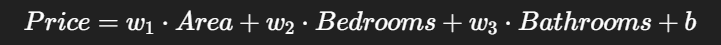


- fit() trains the model using training data

**9. Model Coefficients**

In [11]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coeff_df


,Feature,Coefficient
0,avg_income,21.437583
1,avg_area_house_age,165337.433096
2,avg_area_num_rooms,122385.801481
3,avg_bedrooms,-87.003861
4,avg_population,15.107113


- Shows how much each feature contributes to price
- Higher coefficient → stronger impact

**10. Make Predictions**

In [12]:
y_pred = model.predict(X_test)


- Predicts house prices for unseen test data

**11. Model Evaluation**

In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 83034.97988314604
MSE: 10631960441.627758
RMSE: 103111.39821391115
R2 Score: 0.9172709716777022


- MAE → average absolute error
- MSE → squared error penalty
- RMSE → interpretable error
- R² Score → how well model explains variance (closer to 1 is better)

**11. Visualizing Actual vs Predicted Prices**

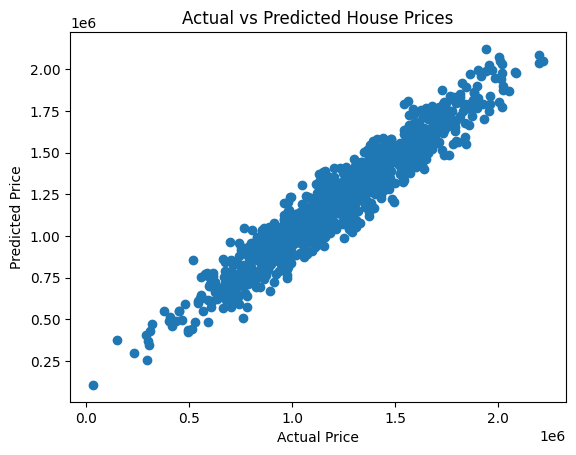

In [14]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()


- Points close to diagonal → good predictions
- Helps visually evaluate model performance

**13. Residual Analysis**

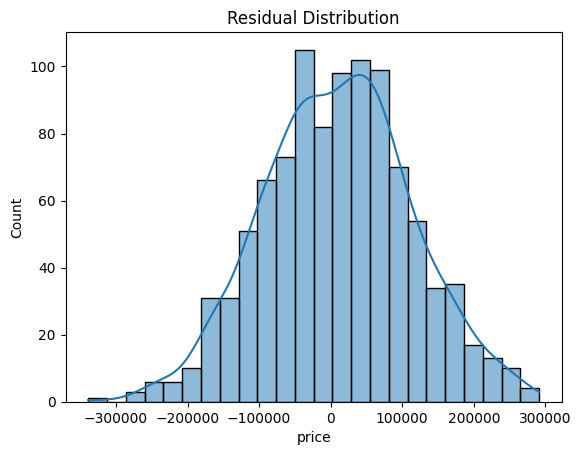

In [18]:
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

- Residuals should be normally distributed
- Indicates good linear regression fit

**14. Predict Price for a New House**

In [19]:
new_house = [[75000, 6, 7, 4, 30000]]
predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])


Predicted House Price: 1279993.2087542536


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


- Predicts price using trained model
- Demonstrates real-world usage